# Notebook 04 — Model Training

Trains all five forecasting models on both datasets:

| # | Model | Type |
|---|---|---|
| 1 | Random Forest | Traditional ML |
| 2 | XGBoost | Traditional ML |
| 3 | LSTM | Deep Learning |
| 4 | GRU | Deep Learning |
| 5 | CNN-LSTM | Deep Learning |

Each model is trained on **PJM East** then **UCI Household**.
All trained models and predictions are saved to `models/`.

> **Tip:** For faster training of deep learning models, run this notebook on Google Colab (Runtime → Change runtime type → GPU).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, warnings, time

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, GRU, Dense, Dropout,
                                      Conv1D, MaxPooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

PROC   = os.path.join('..', 'data', 'processed')
MODELS = os.path.join('..', 'models')
os.makedirs(MODELS, exist_ok=True)

WINDOW = 24
BATCH  = 512
EPOCHS = 30

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.21.0
GPU        : False


In [2]:
# ── Load sequences & scalers ──────────────────────────────────────
pjm_seq = np.load(os.path.join(PROC, 'pjm_sequences.npz'))
uci_seq = np.load(os.path.join(PROC, 'uci_sequences.npz'))

X_tr_p, X_te_p = pjm_seq['X_train'], pjm_seq['X_test']
y_tr_p, y_te_p = pjm_seq['y_train'], pjm_seq['y_test']

X_tr_u, X_te_u = uci_seq['X_train'], uci_seq['X_test']
y_tr_u, y_te_u = uci_seq['y_train'], uci_seq['y_test']

with open(os.path.join(PROC, 'pjm_scaler.pkl'), 'rb') as f:
    pjm_sc = pickle.load(f)
with open(os.path.join(PROC, 'uci_scaler.pkl'), 'rb') as f:
    uci_sc = pickle.load(f)

# 3-D reshape for deep learning: (n, 24) → (n, 24, 1)
X_tr_p3 = X_tr_p.reshape(-1, WINDOW, 1)
X_te_p3 = X_te_p.reshape(-1, WINDOW, 1)
X_tr_u3 = X_tr_u.reshape(-1, WINDOW, 1)
X_te_u3 = X_te_u.reshape(-1, WINDOW, 1)

print('PJM  train/test:', X_tr_p.shape, X_te_p.shape)
print('UCI  train/test:', X_tr_u.shape, X_te_u.shape)

# Dictionary to store all predictions (loaded by notebook 05)
results = {}

PJM  train/test: (116294, 24) (29074, 24)
UCI  train/test: (27652, 24) (6913, 24)


In [3]:
# ── Shared helpers ────────────────────────────────────────────────
def inv(arr, sc):
    """Inverse Min-Max scale a 1-D array back to original units."""
    return sc.inverse_transform(arr.reshape(-1, 1)).flatten()

def plot_loss(history, title):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(history.history['loss'],     label='Train loss', lw=1.5)
    ax.plot(history.history['val_loss'], label='Val loss',   lw=1.5)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    ax.legend(); plt.tight_layout(); plt.show()

def build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return m

def build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW, 1)),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return m

def build_cnnlstm():
    m = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=(WINDOW, 1)),
        MaxPooling1D(pool_size=2),
        Conv1D(32, kernel_size=3, activation='relu'),
        LSTM(50),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return m

es       = EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss', verbose=0)
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=3, verbose=0)

print('Helpers defined.')
print('LSTM  params:', build_lstm().count_params())
print('GRU   params:', build_gru().count_params())
print('CNNLSTM params:', build_cnnlstm().count_params())

Helpers defined.
LSTM  params: 29345
GRU   params: 22305
CNNLSTM params: 23083


---
## 1 — Random Forest

In [4]:
# ── RF on PJM ─────────────────────────────────────────────────────
print('Training Random Forest on PJM East …')
t0  = time.time()
rf_p = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42, verbose=0)
rf_p.fit(X_tr_p, y_tr_p)
elapsed = time.time() - t0
print(f'  Done in {elapsed:.1f}s')

pred_rf_p = rf_p.predict(X_te_p)
results['RF_PJM'] = {'pred': inv(pred_rf_p, pjm_sc), 'true': inv(y_te_p, pjm_sc)}

with open(os.path.join(MODELS, 'rf_pjm.pkl'), 'wb') as f:
    pickle.dump(rf_p, f)
print('  Saved → models/rf_pjm.pkl')

Training Random Forest on PJM East …


  Done in 23.4s


  Saved → models/rf_pjm.pkl


In [5]:
# ── RF on UCI ─────────────────────────────────────────────────────
print('Training Random Forest on UCI Household …')
t0   = time.time()
rf_u = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42, verbose=0)
rf_u.fit(X_tr_u, y_tr_u)
elapsed = time.time() - t0
print(f'  Done in {elapsed:.1f}s')

pred_rf_u = rf_u.predict(X_te_u)
results['RF_UCI'] = {'pred': inv(pred_rf_u, uci_sc), 'true': inv(y_te_u, uci_sc)}

with open(os.path.join(MODELS, 'rf_uci.pkl'), 'wb') as f:
    pickle.dump(rf_u, f)
print('  Saved → models/rf_uci.pkl')

Training Random Forest on UCI Household …


  Done in 5.2s


  Saved → models/rf_uci.pkl


---
## 2 — XGBoost

In [6]:
# ── XGBoost on PJM ────────────────────────────────────────────────
print('Training XGBoost on PJM East …')
t0    = time.time()
xgb_p = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                           max_depth=6, subsample=0.8,
                           colsample_bytree=0.8, random_state=42,
                           verbosity=0, n_jobs=-1)
xgb_p.fit(X_tr_p, y_tr_p,
           eval_set=[(X_te_p, y_te_p)],
           verbose=False)
elapsed = time.time() - t0
print(f'  Done in {elapsed:.1f}s')

pred_xgb_p = xgb_p.predict(X_te_p)
results['XGB_PJM'] = {'pred': inv(pred_xgb_p, pjm_sc), 'true': inv(y_te_p, pjm_sc)}

xgb_p.save_model(os.path.join(MODELS, 'xgb_pjm.json'))
print('  Saved → models/xgb_pjm.json')

Training XGBoost on PJM East …


  Done in 1.2s
  Saved → models/xgb_pjm.json


In [7]:
# ── XGBoost on UCI ────────────────────────────────────────────────
print('Training XGBoost on UCI Household …')
t0    = time.time()
xgb_u = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                           max_depth=6, subsample=0.8,
                           colsample_bytree=0.8, random_state=42,
                           verbosity=0, n_jobs=-1)
xgb_u.fit(X_tr_u, y_tr_u,
           eval_set=[(X_te_u, y_te_u)],
           verbose=False)
elapsed = time.time() - t0
print(f'  Done in {elapsed:.1f}s')

pred_xgb_u = xgb_u.predict(X_te_u)
results['XGB_UCI'] = {'pred': inv(pred_xgb_u, uci_sc), 'true': inv(y_te_u, uci_sc)}

xgb_u.save_model(os.path.join(MODELS, 'xgb_uci.json'))
print('  Saved → models/xgb_uci.json')

Training XGBoost on UCI Household …


  Done in 0.9s
  Saved → models/xgb_uci.json


---
## 3 — LSTM

Training LSTM on PJM East …


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

...

201/205 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 8.7401e-04 - mae: 0.0220

203/205 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 8.7391e-04 - mae: 0.0220

205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 8.7381e-04 - mae: 0.0220

205/205 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - loss: 8.6337e-04 - mae: 0.0219 - val_loss: 3.2975e-04 - val_mae: 0.0137 - learning_rate: 6.2500e-05



Done in 322.3s  |  Epochs run: 30


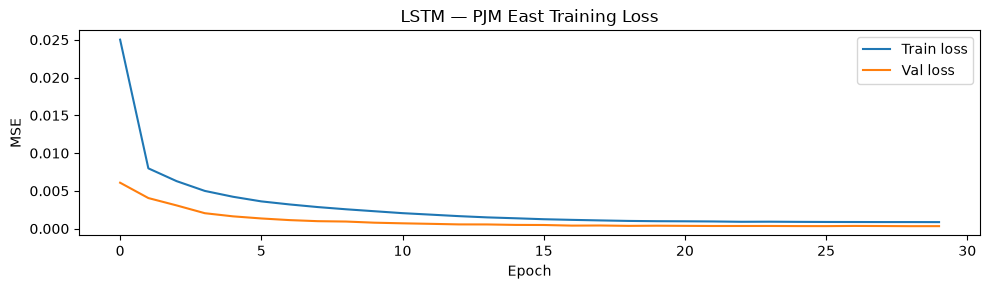

Saved → models/lstm_pjm.keras


In [8]:
# ── LSTM on PJM ───────────────────────────────────────────────────
print('Training LSTM on PJM East …')
lstm_p = build_lstm()
lstm_p.summary()

t0 = time.time()
hist_lstm_p = lstm_p.fit(
    X_tr_p3, y_tr_p,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.1,
    callbacks=[es, reduce_lr],
    verbose=1
)
elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s  |  Epochs run: {len(hist_lstm_p.history["loss"])}')
plot_loss(hist_lstm_p, 'LSTM — PJM East Training Loss')

pred_lstm_p = lstm_p.predict(X_te_p3, verbose=0).flatten()
results['LSTM_PJM'] = {'pred': inv(pred_lstm_p, pjm_sc), 'true': inv(y_te_p, pjm_sc)}

lstm_p.save(os.path.join(MODELS, 'lstm_pjm.keras'))
with open(os.path.join(MODELS, 'hist_lstm_pjm.pkl'), 'wb') as f:
    pickle.dump(hist_lstm_p.history, f)
print('Saved → models/lstm_pjm.keras')

Training LSTM on UCI Household …
Epoch 1/30


 1/49 ━━━━━━━━━━━━━━━━━━━━ 1:33 2s/step - loss: 0.1911 - mae: 0.3371

 3/49 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1672 - mae: 0.3036

 5/49 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.1512 - mae: 0.2830

 7/49 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.1395 - mae: 0.2699

...

45/49 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0403 - mae: 0.1536

47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0403 - mae: 0.1535

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0403 - mae: 0.1534

49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0399 - mae: 0.1520 - val_loss: 0.0396 - val_mae: 0.1532 - learning_rate: 5.0000e-04



Done in 15.3s  |  Epochs run: 5


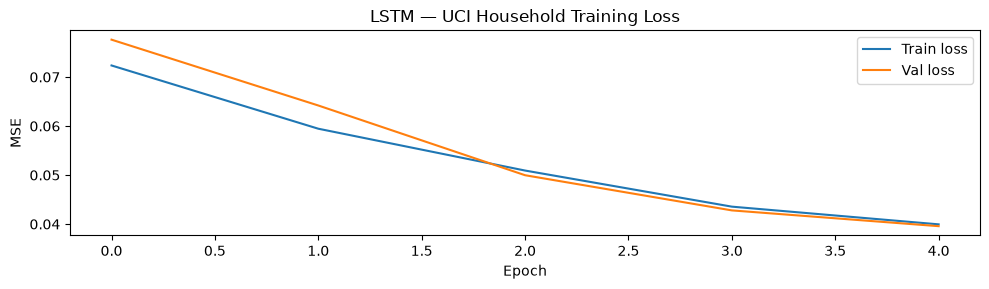

Saved → models/lstm_uci.keras


In [9]:
# ── LSTM on UCI ───────────────────────────────────────────────────
print('Training LSTM on UCI Household …')
lstm_u = build_lstm()

t0 = time.time()
hist_lstm_u = lstm_u.fit(
    X_tr_u3, y_tr_u,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.1,
    callbacks=[es, reduce_lr],
    verbose=1
)
elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s  |  Epochs run: {len(hist_lstm_u.history["loss"])}')
plot_loss(hist_lstm_u, 'LSTM — UCI Household Training Loss')

pred_lstm_u = lstm_u.predict(X_te_u3, verbose=0).flatten()
results['LSTM_UCI'] = {'pred': inv(pred_lstm_u, uci_sc), 'true': inv(y_te_u, uci_sc)}

lstm_u.save(os.path.join(MODELS, 'lstm_uci.keras'))
with open(os.path.join(MODELS, 'hist_lstm_uci.pkl'), 'wb') as f:
    pickle.dump(hist_lstm_u.history, f)
print('Saved → models/lstm_uci.keras')

---
## 4 — GRU

Training GRU on PJM East …
Epoch 1/30


  1/205 ━━━━━━━━━━━━━━━━━━━━ 7:41 2s/step - loss: 0.4209 - mae: 0.6105

  3/205 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 0.3703 - mae: 0.5678

  5/205 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 0.3305 - mae: 0.5299

  6/205 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.3140 - mae: 0.5128

...

202/205 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0033 - mae: 0.0434

203/205 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0033 - mae: 0.0434

204/205 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0033 - mae: 0.0434

205/205 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 0.0032 - mae: 0.0430 - val_loss: 9.2713e-04 - val_mae: 0.0238 - learning_rate: 5.0000e-04



Done in 65.0s  |  Epochs run: 5


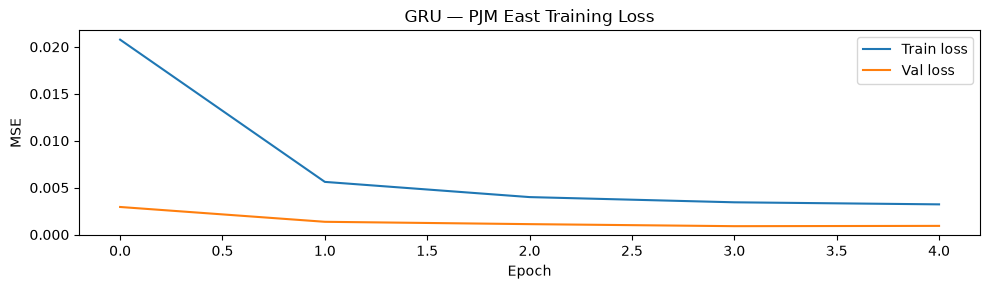

Saved → models/gru_pjm.keras


In [10]:
# ── GRU on PJM ────────────────────────────────────────────────────
print('Training GRU on PJM East …')
gru_p = build_gru()

t0 = time.time()
hist_gru_p = gru_p.fit(
    X_tr_p3, y_tr_p,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.1,
    callbacks=[es, reduce_lr],
    verbose=1
)
elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s  |  Epochs run: {len(hist_gru_p.history["loss"])}')
plot_loss(hist_gru_p, 'GRU — PJM East Training Loss')

pred_gru_p = gru_p.predict(X_te_p3, verbose=0).flatten()
results['GRU_PJM'] = {'pred': inv(pred_gru_p, pjm_sc), 'true': inv(y_te_p, pjm_sc)}

gru_p.save(os.path.join(MODELS, 'gru_pjm.keras'))
with open(os.path.join(MODELS, 'hist_gru_pjm.pkl'), 'wb') as f:
    pickle.dump(hist_gru_p.history, f)
print('Saved → models/gru_pjm.keras')

Training GRU on UCI Household …
Epoch 1/30


 1/49 ━━━━━━━━━━━━━━━━━━━━ 1:53 2s/step - loss: 0.1384 - mae: 0.2761

 3/49 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.1282 - mae: 0.2586

 5/49 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.1185 - mae: 0.2463

 6/49 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1142 - mae: 0.2416

...

46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0354 - mae: 0.1378

47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0354 - mae: 0.1378

48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0353 - mae: 0.1378

49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0347 - mae: 0.1368 - val_loss: 0.0374 - val_mae: 0.1421 - learning_rate: 5.0000e-04



Done in 17.7s  |  Epochs run: 5


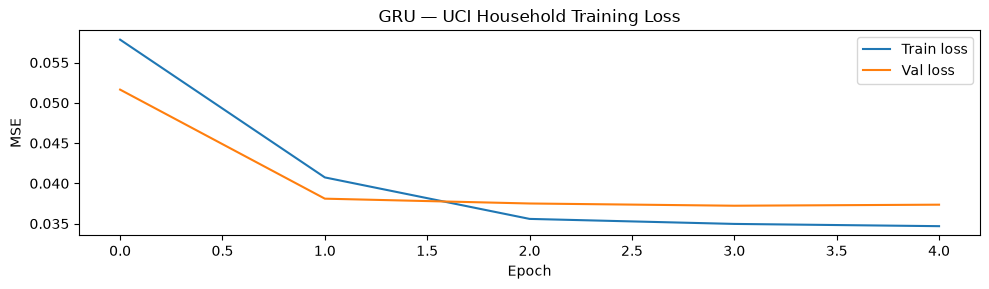

Saved → models/gru_uci.keras


In [11]:
# ── GRU on UCI ────────────────────────────────────────────────────
print('Training GRU on UCI Household …')
gru_u = build_gru()

t0 = time.time()
hist_gru_u = gru_u.fit(
    X_tr_u3, y_tr_u,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.1,
    callbacks=[es, reduce_lr],
    verbose=1
)
elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s  |  Epochs run: {len(hist_gru_u.history["loss"])}')
plot_loss(hist_gru_u, 'GRU — UCI Household Training Loss')

pred_gru_u = gru_u.predict(X_te_u3, verbose=0).flatten()
results['GRU_UCI'] = {'pred': inv(pred_gru_u, uci_sc), 'true': inv(y_te_u, uci_sc)}

gru_u.save(os.path.join(MODELS, 'gru_uci.keras'))
with open(os.path.join(MODELS, 'hist_gru_uci.pkl'), 'wb') as f:
    pickle.dump(hist_gru_u.history, f)
print('Saved → models/gru_uci.keras')

---
## 5 — CNN-LSTM Hybrid

Training CNN-LSTM on PJM East …
Epoch 1/30


  1/205 ━━━━━━━━━━━━━━━━━━━━ 6:30 2s/step - loss: 0.3359 - mae: 0.5445

  6/205 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.2821 - mae: 0.4921

  9/205 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.2567 - mae: 0.4630

 12/205 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.2342 - mae: 0.4348

...

194/205 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0026 - mae: 0.0396

198/205 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0026 - mae: 0.0396

202/205 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0026 - mae: 0.0396

205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0026 - mae: 0.0393 - val_loss: 0.0011 - val_mae: 0.0262 - learning_rate: 5.0000e-04



Done in 20.9s  |  Epochs run: 5


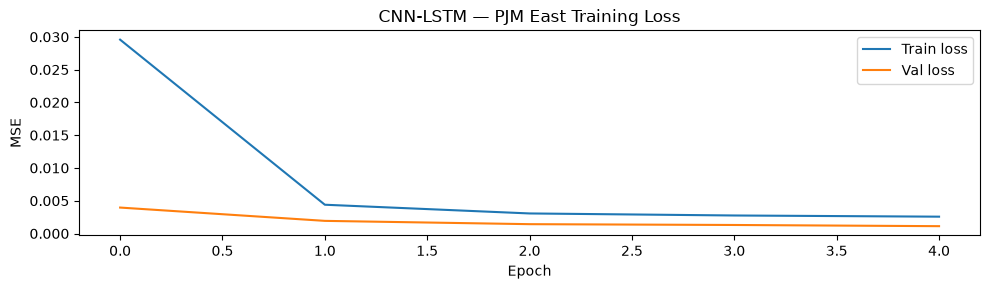

Saved → models/cnnlstm_pjm.keras


In [12]:
# ── CNN-LSTM on PJM ───────────────────────────────────────────────
print('Training CNN-LSTM on PJM East …')
cnn_p = build_cnnlstm()

t0 = time.time()
hist_cnn_p = cnn_p.fit(
    X_tr_p3, y_tr_p,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.1,
    callbacks=[es, reduce_lr],
    verbose=1
)
elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s  |  Epochs run: {len(hist_cnn_p.history["loss"])}')
plot_loss(hist_cnn_p, 'CNN-LSTM — PJM East Training Loss')

pred_cnn_p = cnn_p.predict(X_te_p3, verbose=0).flatten()
results['CNNLSTM_PJM'] = {'pred': inv(pred_cnn_p, pjm_sc), 'true': inv(y_te_p, pjm_sc)}

cnn_p.save(os.path.join(MODELS, 'cnnlstm_pjm.keras'))
with open(os.path.join(MODELS, 'hist_cnnlstm_pjm.pkl'), 'wb') as f:
    pickle.dump(hist_cnn_p.history, f)
print('Saved → models/cnnlstm_pjm.keras')

Training CNN-LSTM on UCI Household …
Epoch 1/30


 1/49 ━━━━━━━━━━━━━━━━━━━━ 1:10 1s/step - loss: 0.1390 - mae: 0.2849

 6/49 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1345 - mae: 0.2664

11/49 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1209 - mae: 0.2509

15/49 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1133 - mae: 0.2445

...

39/49 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0347 - mae: 0.1371

43/49 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0346 - mae: 0.1370

47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0345 - mae: 0.1368

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0337 - mae: 0.1349 - val_loss: 0.0352 - val_mae: 0.1432 - learning_rate: 5.0000e-04



Done in 5.5s  |  Epochs run: 5


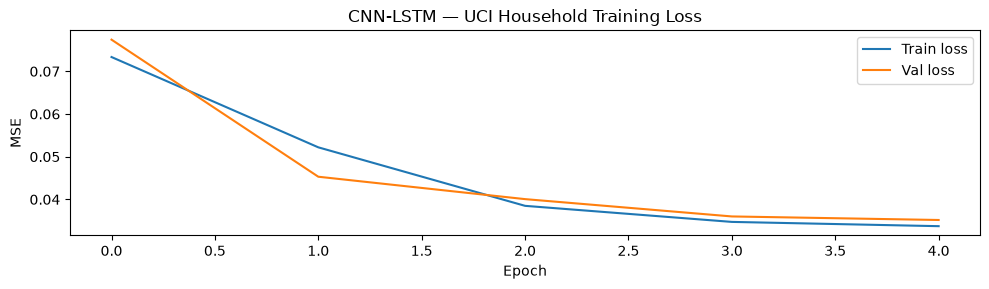

Saved → models/cnnlstm_uci.keras


In [13]:
# ── CNN-LSTM on UCI ───────────────────────────────────────────────
print('Training CNN-LSTM on UCI Household …')
cnn_u = build_cnnlstm()

t0 = time.time()
hist_cnn_u = cnn_u.fit(
    X_tr_u3, y_tr_u,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.1,
    callbacks=[es, reduce_lr],
    verbose=1
)
elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s  |  Epochs run: {len(hist_cnn_u.history["loss"])}')
plot_loss(hist_cnn_u, 'CNN-LSTM — UCI Household Training Loss')

pred_cnn_u = cnn_u.predict(X_te_u3, verbose=0).flatten()
results['CNNLSTM_UCI'] = {'pred': inv(pred_cnn_u, uci_sc), 'true': inv(y_te_u, uci_sc)}

cnn_u.save(os.path.join(MODELS, 'cnnlstm_uci.keras'))
with open(os.path.join(MODELS, 'hist_cnnlstm_uci.pkl'), 'wb') as f:
    pickle.dump(hist_cnn_u.history, f)
print('Saved → models/cnnlstm_uci.keras')

---
## Save All Predictions

In [14]:
# Save the combined results dict for notebook 05 (evaluation)
with open(os.path.join(MODELS, 'all_predictions.pkl'), 'wb') as f:
    pickle.dump(results, f)

print('=' * 55)
print('ALL MODELS TRAINED & SAVED')
print('=' * 55)
print(f'\nKeys in results dict:')
for k in results:
    pred = results[k]['pred']
    true = results[k]['true']
    print(f'  {k:15s}  pred shape={pred.shape}  range=[{pred.min():.3f}, {pred.max():.3f}]')
print(f'\nSaved to : {os.path.abspath(MODELS)}')
print("\nFiles saved:")
for f in sorted(os.listdir(MODELS)):
    size = os.path.getsize(os.path.join(MODELS, f)) / 1024
    print(f'  {f:<35s} {size:>8.1f} KB')

ALL MODELS TRAINED & SAVED

Keys in results dict:
  RF_PJM           pred shape=(29074,)  range=[19500.670, 47761.625]
  RF_UCI           pred shape=(6913,)  range=[0.241, 3.064]
  XGB_PJM          pred shape=(29074,)  range=[19714.156, 47909.891]
  XGB_UCI          pred shape=(6913,)  range=[0.221, 3.174]
  LSTM_PJM         pred shape=(29074,)  range=[19592.496, 49670.598]
  LSTM_UCI         pred shape=(6913,)  range=[0.559, 1.573]
  GRU_PJM          pred shape=(29074,)  range=[20730.922, 47024.984]
  GRU_UCI          pred shape=(6913,)  range=[0.531, 2.285]
  CNNLSTM_PJM      pred shape=(29074,)  range=[20463.477, 51236.371]
  CNNLSTM_UCI      pred shape=(6913,)  range=[0.526, 1.571]

Saved to : /Users/muhammadusman/Desktop/final theisis 2026/ali haider/implementation/models

Files saved:
  all_predictions.pkl                   2250.3 KB
  cnnlstm_pjm.keras                      308.5 KB
  cnnlstm_uci.keras                      308.5 KB
  gru_pjm.keras                          297.1 K